In [1]:
def extract_RHEA_ID_and_CHEBI_IDs(entry):
    RHEA_ID = entry[0][len("ENTRY"): -1]
    RHEA_ID = RHEA_ID.split(" ")[-1]
    CHEBI_IDs = entry[2][len("EQUATION"): -1]
    CHEBI_IDs = CHEBI_IDs[CHEBI_IDs.index("CHEBI"):]
    return(RHEA_ID, CHEBI_IDs)

def get_substrate_IDs(IDs):
    possible_separations = [" = ", " => ", " <=> "]
    for separation in possible_separations:
        if separation in IDs:
            IDs = IDs.split(separation)
            reactants_ids = IDs[0]
            reactants_ids = reactants_ids.replace(" + ", ";")
            reactants_ids = reactants_ids.split(";")
            reactants_ids = ";".join([ID.split(" ")[-1] for ID in reactants_ids])
            products_ids = IDs[1]
            products_ids = products_ids.replace(" + ", ";")
            products_ids = products_ids.split(";")
            products_ids = ";".join([ID.split(" ")[-1] for ID in products_ids])
            return(reactants_ids, products_ids)



In [2]:
import pandas as pd
import os

df_RHEA = pd.DataFrame(columns = ["RHEA ID", "reactants", "products", "EC number"])

file1 = open(os.path.join("rhea-reactions.txt"), 'r')
lines = file1.readlines()
entries = []
entry = []
from tqdm import tqdm
for line in lines:
    if '///\n' in line:
        entry.append(line)
        RHEA_ID, CHEBI_IDs = extract_RHEA_ID_and_CHEBI_IDs(entry)
        reactants, products = get_substrate_IDs(IDs = CHEBI_IDs)
        # df_RHEA = pd.concat((df_RHEA, pd.DataFrame({"RHEA ID" : [RHEA_ID], "CHEBI_ID_list" : [CHEBI_ID_list]})), ignore_index = True)
        entries.append(entry)
        entry=[]
    else:
        entry.append(line)

In [3]:
from tqdm import tqdm
import contextlib
import joblib

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""

    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

def get_substrates(entry):
    RHEA_ID, CHEBI_IDs = extract_RHEA_ID_and_CHEBI_IDs(entry)
    reactants, products = get_substrate_IDs(IDs = CHEBI_IDs)
    return pd.DataFrame({"RHEA_ID" : [RHEA_ID], "reactants" : [reactants], "products": [products]})

from joblib import Parallel, delayed

parallel_callback = Parallel(n_jobs=-1, backend="multiprocessing", prefer="threads")
with tqdm_joblib(tqdm(desc="get substrates", total=len(entries))):
    res = parallel_callback(
        delayed(get_substrates)(entry)
        for entry in entries)
    
df_RHEA = pd.concat(res, ignore_index = True)
df_RHEA["RHEA_ID"] = [float(ID.split(":")[-1]) for ID in df_RHEA["RHEA_ID"]]


get substrates:   0%|          | 0/65640 [00:00<?, ?it/s]

get substrates: 100%|██████████| 65640/65640 [00:49<00:00, 1318.32it/s]


In [4]:
rhea_to_ec = pd.read_csv("rhea2ec.tsv", sep="\t")

In [5]:
rhea_to_ec

,RHEA_ID,DIRECTION,MASTER_ID,ID
0,10000,UN,10000,3.5.1.50
1,10004,UN,10004,5.99.1.1
2,10012,UN,10012,1.5.3.6
3,10016,UN,10016,3.1.1.49
4,10020,UN,10020,1.5.1.10
...,...,...,...,...
7630,77787,UN,77787,1.5.3.25
7631,77879,UN,77879,1.5.3.26
7632,77883,UN,77883,3.1.3.109
7633,77903,UN,77903,1.3.2.4


In [6]:
ec_number = None
df_RHEA_copy = df_RHEA.copy()
for i, row in df_RHEA.iterrows():
    values = rhea_to_ec[rhea_to_ec["RHEA_ID"] == row["RHEA_ID"]]["ID"].values
    if values.size > 0:
        df_RHEA_copy.at[i, "EC number"] = values[0]

In [7]:
df_RHEA_copy = df_RHEA_copy[~df_RHEA_copy["EC number"].isna()]

In [8]:
df_RHEA_copy

,RHEA_ID,reactants,products,EC number
0,10000.0,CHEBI:15377;CHEBI:16459,CHEBI:28938;CHEBI:31011,3.5.1.50
4,10004.0,CHEBI:17484,CHEBI:16017,5.99.1.1
12,10012.0,CHEBI:58413;CHEBI:15377;CHEBI:15379,CHEBI:58682;CHEBI:16240,1.5.3.6
16,10016.0,CHEBI:15377;CHEBI:16353,CHEBI:30023;CHEBI:15354;CHEBI:15378,3.1.1.49
20,10020.0,CHEBI:15377;CHEBI:57951;CHEBI:58349,CHEBI:58321;CHEBI:15378;CHEBI:29985;CHEBI:57783,1.5.1.10
...,...,...,...,...
65160,77787.0,CHEBI:228143;CHEBI:15377;CHEBI:15379,CHEBI:16609;CHEBI:58001;CHEBI:16240,1.5.3.25
65252,77879.0,CHEBI:228143;CHEBI:15377;CHEBI:15379,CHEBI:228165;CHEBI:17478;CHEBI:16240,1.5.3.26
65256,77883.0,CHEBI:57870;CHEBI:15377,CHEBI:71680;CHEBI:43474,3.1.3.109
65276,77903.0,CHEBI:29034;CHEBI:30031,CHEBI:29033;CHEBI:29806;CHEBI:15378,1.3.2.4


In [9]:
rhea2uniprot = pd.read_csv("rhea2uniprot_sprot.tsv", sep="\t")

In [10]:
df_RHEA_copy = pd.merge(df_RHEA_copy, rhea2uniprot, on = "RHEA_ID", how = "inner")

In [11]:
df_RHEA_copy

,RHEA_ID,reactants,products,EC number,DIRECTION,MASTER_ID,ID
0,10012.0,CHEBI:58413;CHEBI:15377;CHEBI:15379,CHEBI:58682;CHEBI:16240,1.5.3.6,UN,10012,P08159
1,10016.0,CHEBI:15377;CHEBI:16353,CHEBI:30023;CHEBI:15354;CHEBI:15378,3.1.1.49,UN,10016,Q3ZFI4
2,10020.0,CHEBI:15377;CHEBI:57951;CHEBI:58349,CHEBI:58321;CHEBI:15378;CHEBI:29985;CHEBI:57783,1.5.1.10,UN,10020,O59711
3,10020.0,CHEBI:15377;CHEBI:57951;CHEBI:58349,CHEBI:58321;CHEBI:15378;CHEBI:29985;CHEBI:57783,1.5.1.10,UN,10020,P38999
4,10020.0,CHEBI:15377;CHEBI:57951;CHEBI:58349,CHEBI:58321;CHEBI:15378;CHEBI:29985;CHEBI:57783,1.5.1.10,UN,10020,Q54NG9
...,...,...,...,...,...,...,...
261402,77643.0,CHEBI:194156;CHEBI:15377,CHEBI:456215;CHEBI:43474,3.1.3.7,UN,77643,Q8GY63
261403,77643.0,CHEBI:194156;CHEBI:15377,CHEBI:456215;CHEBI:43474,3.1.3.7,UN,77643,Q9M0Y6
261404,77643.0,CHEBI:194156;CHEBI:15377,CHEBI:456215;CHEBI:43474,3.1.3.7,UN,77643,Q9Z0S1
261405,77643.0,CHEBI:194156;CHEBI:15377,CHEBI:456215;CHEBI:43474,3.1.3.7,UN,77643,Q9Z1N4


In [12]:
df_RHEA_copy["DIRECTION"].unique()

array(['UN'], dtype=object)

In [14]:

def add_line(j, row, compound, decomposed_dataset):
    decomposed_dataset.at[j, "RHEA_ID"] = row["RHEA_ID"]
    decomposed_dataset.at[j, "EC number"] = row["EC number"]
    decomposed_dataset.at[j, "CHEBI_ID"] = compound
    decomposed_dataset.at[j, "uniprot_id"] = row["ID"]
    return decomposed_dataset


def create_decomposed_dataset(i, row):
    decomposed_dataset = pd.DataFrame(columns = ["RHEA_ID", "EC number", "CHEBI_ID", "uniprot_id"])
    j = 0
    reactants = row["reactants"].split(";")
    products = row["products"].split(";")
    if row["DIRECTION"] == "UN":
        for reactant in reactants:
            decomposed_dataset = add_line(j, row, reactant, decomposed_dataset)
            j += 1
        for product in products:
            decomposed_dataset = add_line(j, row, product, decomposed_dataset)
            j += 1
    elif row["DIRECTION"] == "LR":
        for reactant in reactants:
            decomposed_dataset = add_line(j, row, reactant, decomposed_dataset)
            j += 1
    elif row["DIRECTION"] == "RL":
        for product in products:
            decomposed_dataset = add_line(j, row, product, decomposed_dataset)
            j += 1
    return decomposed_dataset

parallel_callback = Parallel(n_jobs=-1, backend="multiprocessing", prefer="threads")
with tqdm_joblib(tqdm(desc="create dataset", total=len(df_RHEA_copy))):
    res = parallel_callback(
        delayed(create_decomposed_dataset)(i, row)
        for i, row in df_RHEA_copy.iterrows())
    
df_RHEA = pd.concat(res, ignore_index = True)

create dataset: 100%|██████████| 261407/261407 [11:00<00:00, 395.76it/s]


In [16]:
df_RHEA.to_csv("df_RHEA.csv", index = False)

In [26]:
import pandas as pd
df_RHEA = pd.read_csv("df_RHEA.csv")
df_RHEA

,RHEA_ID,EC number,CHEBI_ID,uniprot_id
0,10012.0,1.5.3.6,CHEBI:58413,P08159
1,10012.0,1.5.3.6,CHEBI:15377,P08159
2,10012.0,1.5.3.6,CHEBI:15379,P08159
3,10012.0,1.5.3.6,CHEBI:58682,P08159
4,10012.0,1.5.3.6,CHEBI:16240,P08159
...,...,...,...,...
1289197,77643.0,3.1.3.7,CHEBI:43474,Q9Z1N4
1289198,77883.0,3.1.3.109,CHEBI:57870,F8D9F4
1289199,77883.0,3.1.3.109,CHEBI:15377,F8D9F4
1289200,77883.0,3.1.3.109,CHEBI:71680,F8D9F4


In [3]:
rhea_chebi = pd.read_csv("rhea-chebi-smiles.tsv", sep="\t", header=None)
rhea_chebi.columns = ["CHEBI_ID", "SMILES"]
rhea_chebi

,CHEBI_ID,SMILES
0,CHEBI:7,CC1=CC[C@@H]2[C@H](C1)C2(C)C
1,CHEBI:20,C=C1[C@H]2CC[C@H](C2)C1(C)C
2,CHEBI:26,CC1=CO[C@@H](O)[C@H]2[C@@H]1CC[C@@H]2C
3,CHEBI:28,C=C[C@](C)(O)CCC=C(C)C
4,CHEBI:31,CC(C)[C@H]1CC[C@H](C)CC1=O
...,...,...
12726,CHEBI:595389,O=C1NC(=O)c2c1c1c3cccc(Cl)c3[nH]c1c1c2c2cccc(C...
12727,CHEBI:597326,Cc1ncc(COP(=O)([O-])[O-])c(C=O)c1O
12728,CHEBI:606564,CCCCC[C@H](O)/C=C/[C@H]1[C@H](O)CC(=O)[C@@H]1C...
12729,CHEBI:606565,O=C([O-])CNC(=O)c1ccccc1


In [4]:
rhea_chebi.drop_duplicates(inplace=True)

In [5]:
df_RHEA.shape

(1289202, 4)

In [6]:
df_RHEA_smiles = pd.merge(df_RHEA, rhea_chebi, on = "CHEBI_ID", how = "inner")
df_RHEA_smiles

,RHEA_ID,EC number,CHEBI_ID,uniprot_id,SMILES
0,10012.0,1.5.3.6,CHEBI:58413,P08159,C[NH+]1CCC[C@@H]1c1ccc(O)nc1
1,42352.0,1.5.99.4,CHEBI:58413,Q59127,C[NH+]1CCC[C@@H]1c1ccc(O)nc1
2,42352.0,1.5.99.4,CHEBI:58413,Q59128,C[NH+]1CCC[C@@H]1c1ccc(O)nc1
3,42352.0,1.5.99.4,CHEBI:58413,Q93NH5,C[NH+]1CCC[C@@H]1c1ccc(O)nc1
4,10012.0,1.5.3.6,CHEBI:15377,P08159,O
...,...,...,...,...,...
1280223,77643.0,3.1.3.7,CHEBI:194156,Q8GY63,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])[O-])...
1280224,77643.0,3.1.3.7,CHEBI:194156,Q9M0Y6,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])[O-])...
1280225,77643.0,3.1.3.7,CHEBI:194156,Q9Z0S1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])[O-])...
1280226,77643.0,3.1.3.7,CHEBI:194156,Q9Z1N4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])[O-])...


In [7]:
swiss_prot_enzymes = pd.read_csv("swiss_prot_enzymes.csv")

In [8]:
swiss_prot_enzymes.drop(["name", "enzyme"], axis=1, inplace=True)

In [9]:
swiss_prot_enzymes.columns = ["uniprot_id", "EC number"]

In [10]:
df_RHEA_smiles_sequences = pd.merge(df_RHEA_smiles, swiss_prot_enzymes, on = "uniprot_id", how = "inner")
df_RHEA_smiles_sequences

,RHEA_ID,EC number_x,CHEBI_ID,uniprot_id,SMILES,EC number_y
0,10012.0,1.5.3.6,CHEBI:58413,P08159,C[NH+]1CCC[C@@H]1c1ccc(O)nc1,MSSKLATPLSIQGEVIYPDDSGFDAIANIWDGRHLQRPSLIARCLS...
1,10012.0,1.5.3.6,CHEBI:15377,P08159,O,MSSKLATPLSIQGEVIYPDDSGFDAIANIWDGRHLQRPSLIARCLS...
2,10012.0,1.5.3.6,CHEBI:15379,P08159,O=O,MSSKLATPLSIQGEVIYPDDSGFDAIANIWDGRHLQRPSLIARCLS...
3,10012.0,1.5.3.6,CHEBI:58682,P08159,C[NH2+]CCCC(=O)c1ccc(O)nc1,MSSKLATPLSIQGEVIYPDDSGFDAIANIWDGRHLQRPSLIARCLS...
4,10012.0,1.5.3.6,CHEBI:16240,P08159,OO,MSSKLATPLSIQGEVIYPDDSGFDAIANIWDGRHLQRPSLIARCLS...
...,...,...,...,...,...,...
1280223,61416.0,5.5.1.34,CHEBI:71494,A0A3Q8GYY4,CC1=COC(O)[C@H]2[C@@H]1CC[C@@H]2C,MGNKKTLEGKVAIVTGGASGIGETAARVFANLGARAVVIADIQSEL...
1280224,61420.0,5.5.1.35,CHEBI:144481,A0A3Q8GLE8,C/C(C=O)=C\CC[C@H](C)/C=C/O,MANNSVMMKKKLEGKVAIVTGGASGIGEATARLFVKYGARAVVIAD...
1280225,61420.0,5.5.1.35,CHEBI:144485,A0A3Q8GLE8,CC1=COC(O)[C@H]2[C@@H](C)CC[C@@H]12,MANNSVMMKKKLEGKVAIVTGGASGIGEATARLFVKYGARAVVIAD...
1280226,70807.0,5.3.1.37,CHEBI:189857,J0MXJ0,O=C[C@H](O)[C@H](O)CS(=O)(=O)[O-],MKVLIGSDKSGFGLKEEVKAYLAGKGYEMTDCGTLDPEQPKPFFEA...


In [11]:
cofactors = pd.read_csv("cofactors.tsv", sep="\t", )

In [12]:
cofactors = cofactors.index.values

In [13]:
df_RHEA_smiles_sequences_without_cofactors =  df_RHEA_smiles_sequences[~df_RHEA_smiles_sequences["CHEBI_ID"].isin(cofactors)]

In [22]:
df_RHEA_smiles_sequences_without_cofactors

,RHEA_ID,EC number_x,CHEBI_ID,uniprot_id,SMILES,EC number_y
0,10012.0,1.5.3.6,CHEBI:58413,P08159,C[NH+]1CCC[C@@H]1c1ccc(O)nc1,MSSKLATPLSIQGEVIYPDDSGFDAIANIWDGRHLQRPSLIARCLS...
1,10012.0,1.5.3.6,CHEBI:15377,P08159,O,MSSKLATPLSIQGEVIYPDDSGFDAIANIWDGRHLQRPSLIARCLS...
2,10012.0,1.5.3.6,CHEBI:15379,P08159,O=O,MSSKLATPLSIQGEVIYPDDSGFDAIANIWDGRHLQRPSLIARCLS...
3,10012.0,1.5.3.6,CHEBI:58682,P08159,C[NH2+]CCCC(=O)c1ccc(O)nc1,MSSKLATPLSIQGEVIYPDDSGFDAIANIWDGRHLQRPSLIARCLS...
5,42352.0,1.5.99.4,CHEBI:58413,Q59127,C[NH+]1CCC[C@@H]1c1ccc(O)nc1,MKLPAIRYASPASIEDACDLLSTDEDSKIIAGGQSLLPVMAMRLAQ...
...,...,...,...,...,...,...
1280223,61416.0,5.5.1.34,CHEBI:71494,A0A3Q8GYY4,CC1=COC(O)[C@H]2[C@@H]1CC[C@@H]2C,MGNKKTLEGKVAIVTGGASGIGETAARVFANLGARAVVIADIQSEL...
1280224,61420.0,5.5.1.35,CHEBI:144481,A0A3Q8GLE8,C/C(C=O)=C\CC[C@H](C)/C=C/O,MANNSVMMKKKLEGKVAIVTGGASGIGEATARLFVKYGARAVVIAD...
1280225,61420.0,5.5.1.35,CHEBI:144485,A0A3Q8GLE8,CC1=COC(O)[C@H]2[C@@H](C)CC[C@@H]12,MANNSVMMKKKLEGKVAIVTGGASGIGEATARLFVKYGARAVVIAD...
1280226,70807.0,5.3.1.37,CHEBI:189857,J0MXJ0,O=C[C@H](O)[C@H](O)CS(=O)(=O)[O-],MKVLIGSDKSGFGLKEEVKAYLAGKGYEMTDCGTLDPEQPKPFFEA...


In [24]:
len(df_RHEA_smiles_sequences_without_cofactors["uniprot_id"].unique())

213719

In [25]:
len(df_RHEA_smiles_sequences_without_cofactors["CHEBI_ID"].unique())

5439

In [14]:
names = pd.read_csv("names.tsv", sep="\t")
names["COMPOUND_ID"] = [f"CHEBI:{ID}" for ID in names["COMPOUND_ID"]]
names

,ID,COMPOUND_ID,TYPE,SOURCE,NAME,ADAPTED,LANGUAGE
0,10952,CHEBI:16478,SYNONYM,KEGG COMPOUND,"N-Acetyl-beta-D-glucosaminyl-1,6-(N-acetyl-bet...",F,en
1,10957,CHEBI:15947,SYNONYM,KEGG COMPOUND,N-Acetyl-beta-D-glucosaminylamine,F,en
2,11955,CHEBI:7853,SYNONYM,KEGG COMPOUND,Oxyacanthine,F,en
3,11965,CHEBI:15379,SYNONYM,KEGG COMPOUND,Oxygen,F,en
4,11966,CHEBI:15379,SYNONYM,KEGG COMPOUND,O2,F,en
...,...,...,...,...,...,...,...
384246,1151625,CHEBI:58942,SYNONYM,ChEBI,cationic amino-acid residues,F,en
384247,1151629,CHEBI:58942,SYNONYM,ChEBI,cationic amino acid residues,F,en
384248,1151630,CHEBI:58942,SYNONYM,ChEBI,cationic amino acid residue,F,en
384249,1151635,CHEBI:58942,SYNONYM,ChEBI,amino acid cation residues,F,en


In [15]:
# convert the values for ID and NAME in the dataframe to dictionary
names_dict = names.set_index('COMPOUND_ID')['NAME'].to_dict()
names_dict

{'CHEBI:16478': '2-acetamido-2-deoxy-beta-D-glucopyranosyl-(1->3)-[2-acetamido-2-deoxy-beta-D-glucopyranosyl-(1->6)]-2-acetamido-2-deoxy-D-galactopyranosyl',
 'CHEBI:15947': 'N-acetyl-beta-D-glucosaminylamine',
 'CHEBI:7853': 'vinetine',
 'CHEBI:15379': 'E 948',
 'CHEBI:7868': 'oxyphencyclimine HCl',
 'CHEBI:27529': "P(1),P(2)-bis(5'-adenosyl) trihydrogen triphosphate",
 'CHEBI:15883': 'GP4G',
 'CHEBI:5350': 'Giganin',
 'CHEBI:5351': 'Gigantine',
 'CHEBI:5355': 'Ginkgolide A',
 'CHEBI:5357': 'BN 52022',
 'CHEBI:5362': 'Girgensonine',
 'CHEBI:5363': 'Gitogenin',
 'CHEBI:5367': 'Gla protein precursor',
 'CHEBI:5374': 'Glaucolide A',
 'CHEBI:5376': 'Glaziovine',
 'CHEBI:5379': 'Glechomanolide',
 'CHEBI:18259': 'CTH/Gb4',
 'CHEBI:17815': 'L-1,2-Diacylglycerol',
 'CHEBI:3': '((R)-3-Hydroxybutanoyl)(n-2)',
 'CHEBI:28234': '(3S,4R)-4,9-dihydro-3H-fluorene-3,4-diol',
 'CHEBI:7': '(+)-alpha-carene',
 'CHEBI:9': '(+)-Adlumine',
 'CHEBI:10': '(+)-Atherospermoline',
 'CHEBI:11': 'Bebeerine',
 'CHE

In [20]:
# make plot of the most common compounds
import matplotlib.pyplot as plt

twenty_compounds_more_used = df_RHEA_smiles_sequences_without_cofactors["CHEBI_ID"].value_counts()[:20].to_dict()
new_dict = {}
for key in twenty_compounds_more_used.keys():
    if key in names_dict:
        new_dict[names_dict[key]] = twenty_compounds_more_used[key]
    else:
        new_dict[key] = twenty_compounds_more_used[key]

new_dict

{'Hydron': 150105,
 'hydrogen hydroxide': 83287,
 'ADP': 47920,
 'diphosphate': 45243,
 "AMP 3'-end residue": 17437,
 'L-glutamate': 14779,
 "5'-S-[(3S)-3-azaniumyl-3-carboxylatopropyl]-5'-thioadenosine": 13961,
 'methanedione': 12995,
 "(nucleoside 5'-monophosphate)n": 11406,
 "3'-phosphonatoadenosine 5'-{3-[(3R)-3-hydroxy-2,2-dimethyl-4-oxo-4-({3-oxo-3-[(2-sulfanylethyl)amino]propyl}amino)butyl] diphosphate}": 9883,
 '(2S)-5-amino-2-ammonio-5-oxopentanoate': 9301,
 'E 948': 9139,
 '(2S)-2-ammonio-4-(methylsulfanyl)butanoate': 7586,
 'nucleoside triphosphate(4-)': 6356,
 'L-serine residue': 5968,
 'acetyl-coenzyme A(4-)': 5599,
 'GTP': 5517,
 'L-threonine residue': 5039,
 'O-phospho-L-serine residue': 4793,
 "5'-deoxyadenosine": 4740}

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

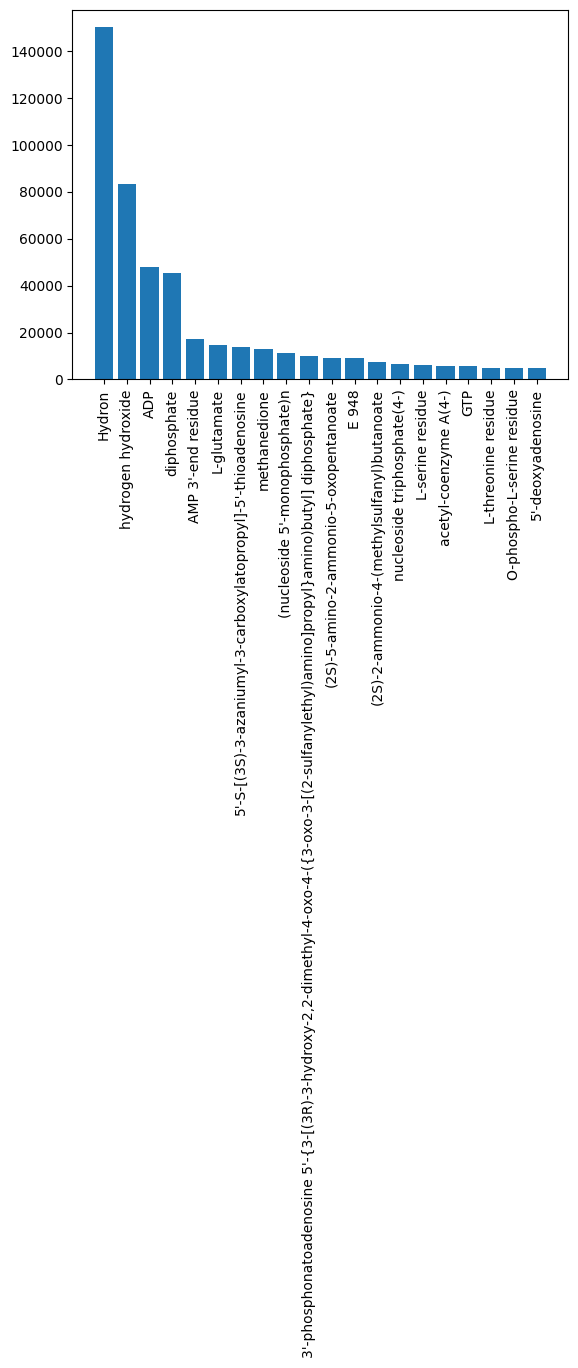

In [21]:
# convert dictionary to plot 
plt.bar(new_dict.keys(), new_dict.values())
plt.xticks(rotation=90)